In [116]:
import sys
sys.path.insert(0, '..')

In [117]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [ ]:
wid = 72
oversample = 4

nwavels = 50#13#6
npoly=5

n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"


# data = np.load("spectrum_iterative.npz", allow_pickle=True)
# weights = data["weights"]
# params = data["params"][()]

# weights_downsampled = ipx.interp1d(np.linspace(0,1,nwavels), np.linspace(0,1,weights.shape[0]), weights)

spectrum_basis_f110w = load_spectrum_basis("F110W", nwavels, npoly)
spectrum_basis_f110w = load_custom_spectrum_basis("../data/iterative_spectrum_basis.npy", nwavels, npoly, direct=True)


spectrum_data = np.load("../data/iterative_basis_binned.npz")

wavels_binned=spectrum_data["wavels_binned"]
wavels_binned_upsampled=spectrum_data["wavels_binned_upsampled"]
vects_binned=spectrum_data["vects_binned"][:,:npoly]
vects_filt_binned=np.array(spectrum_data["vects_filt_binned"])[:,:npoly]
vects_binned_upsampled=spectrum_data["vects_binned_upsampled"][:,:npoly]

ddir = "../data/MAST_2025-12-15T00_12_09.074Z/HST/"

exposures_single = [
    exposure_from_file(ddir + "n9nk29c8q_cal.fits", SinglePointFit(vects_binned, "F110W", precombined=False, wavels=wavels_binned), crop=wid),
    exposure_from_file(ddir + "n9nk29d1q_cal.fits", SinglePointFit(vects_binned, "F110W", precombined=False, wavels=wavels_binned), crop=wid),
    #exposure_from_file(ddir + "n8yj49k6q_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8yj49k8q_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
]


173 93
219 93


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:174: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:174: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


In [119]:
vects_binned.shape

(50, 5)

In [120]:
np.array(vects_filt_binned)

Array([[ 2.91335810e-03,  1.32330789e-05,  1.94716197e-05,
         1.75374170e-05, -1.95005825e-05],
       [ 3.73603136e-02, -1.87147764e-03,  3.82161024e-03,
         4.34194800e-03, -3.74371830e-03],
       [ 2.83465236e-01, -1.13055788e-01,  1.94912333e-01,
         2.19926724e-01, -1.92250597e-01],
       [ 6.47758471e-01, -4.58458665e-01,  7.58203902e-01,
         8.42174040e-01, -7.58134168e-01],
       [ 6.08181854e-01, -4.15872256e-01,  6.54219747e-01,
         7.09898238e-01, -6.65106031e-01],
       [ 6.29330475e-01, -4.56719991e-01,  6.79150604e-01,
         7.20813507e-01, -6.90812488e-01],
       [ 5.80933582e-01, -3.99528850e-01,  5.54304482e-01,
         5.74190825e-01, -5.45133970e-01],
       [ 7.09479711e-01, -6.00757583e-01,  7.67648974e-01,
         7.75183702e-01, -6.87648390e-01],
       [ 4.47062158e-01, -2.46668829e-01,  2.93199149e-01,
         2.87883885e-01, -2.23984418e-01],
       [ 4.28050815e-01, -2.22541859e-01,  2.37333098e-01,
         2.21750982e-01

In [121]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

53920.46725481
U20581
F110W
143.9167
53920.53006731
U20581
F110W
143.9167


In [122]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 79.68,
    "quadrature": {},
}



for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels))#*0.6
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

51.72041175339852
43.42956782576915


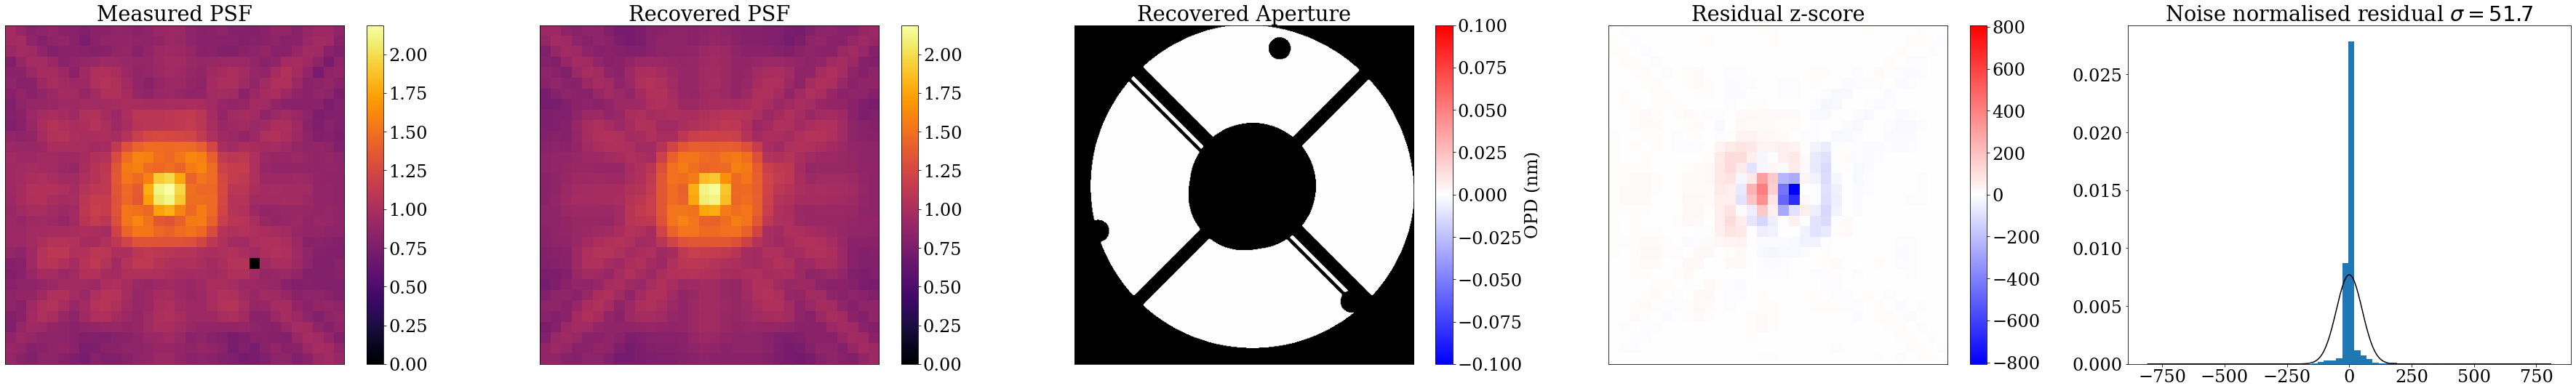

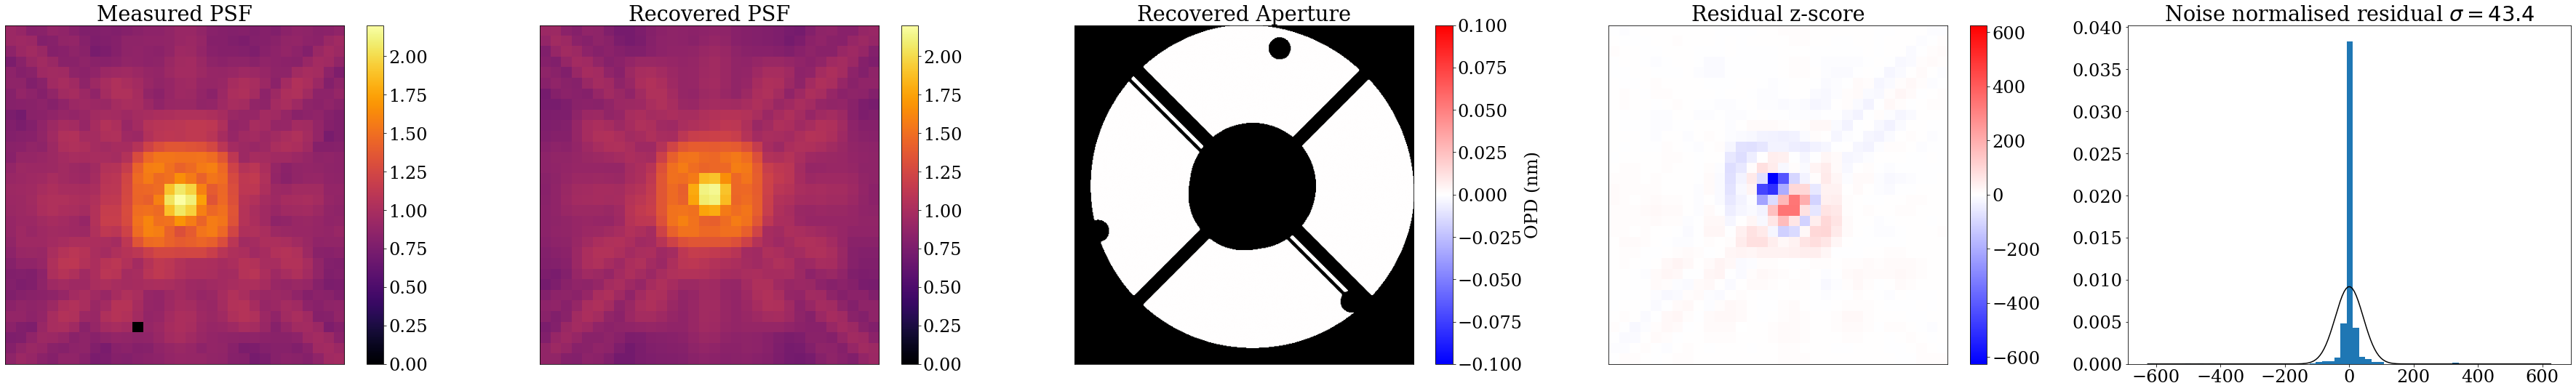

In [123]:
plot_comparison(model_single, params, exposures_single)

In [124]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*0.5, 10),
    "bias": sgd(g*3, 20),
    "cold_mask_shift": sgd(g*0.3, 30),
    "defocus": sgd(g*2, 30),
    "aberrations": sgd(g*0.08, 70),

    
    # #"fnumber": sgd(g*3, 100),
    "cold_mask_shear": sgd(g*0.5, 100),

    "quadrature": sgd(g*25, 250),
}

things_start = {
    "positions": sgd(g*5, 0),
    "spectrum": sgd(g*0.2, 10),
}

groups = list(things.keys())

In [125]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [126]:
opt_params

{'positions': {'n9nk29c8q': Array([0., 0.], dtype=float64),
  'n9nk29d1q': Array([0., 0.], dtype=float64)},
 'spectrum': {'U20581_F110W': Array([107.70748588,   0.        ,   0.        ,   0.        ,
           0.        ], dtype=float64)}}

In [ ]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 20)

[1.41547672e-07 3.08941870e-07 2.27224184e-07 2.17860872e-07
 1.02555766e-03 1.00738352e-02 3.79010053e-02 1.09819639e-01
 2.17784046e-01]


  0%|          | 0/20 [00:00<?, ?it/s]

2328622.2411195324 {'positions': {'n9nk29c8q': Array([-3641799.84712825,   271847.18806878], dtype=float64), 'n9nk29d1q': Array([ 1721917.97372277, -2106137.61404988], dtype=float64)}, 'spectrum': {'U20581_F110W': Array([36641.00647552,  1275.72943863, -1566.74631061,  -481.49513482,
         415.70770874], dtype=float64)}}
2328622.2411195324 {'positions': {'n9nk29c8q': Array([-3641799.84712825,   271847.18806878], dtype=float64), 'n9nk29d1q': Array([ 1721917.97372277, -2106137.61404988], dtype=float64)}, 'spectrum': {'U20581_F110W': Array([36641.00647552,  1275.72943863, -1566.74631061,  -481.49513482,
         415.70770874], dtype=float64)}}


9.12529166002938
9.77096279761692


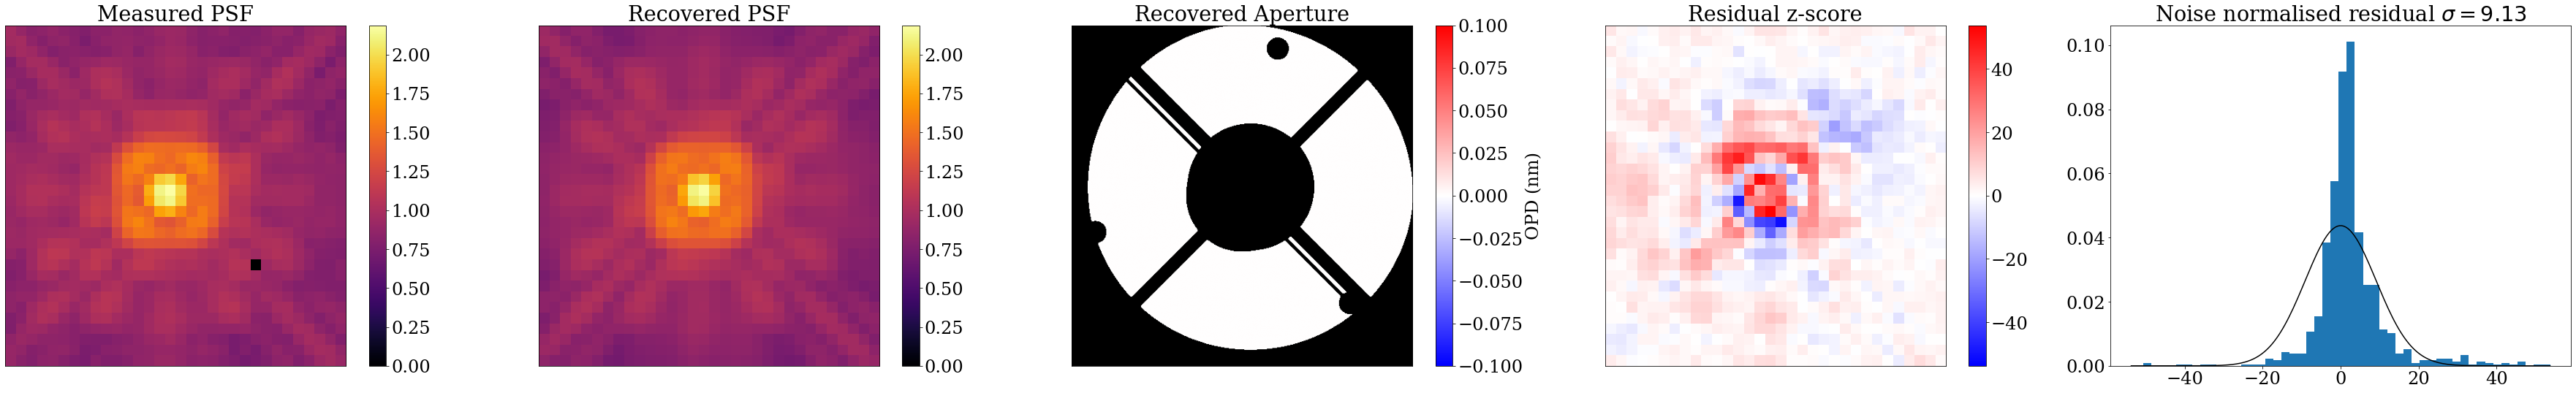

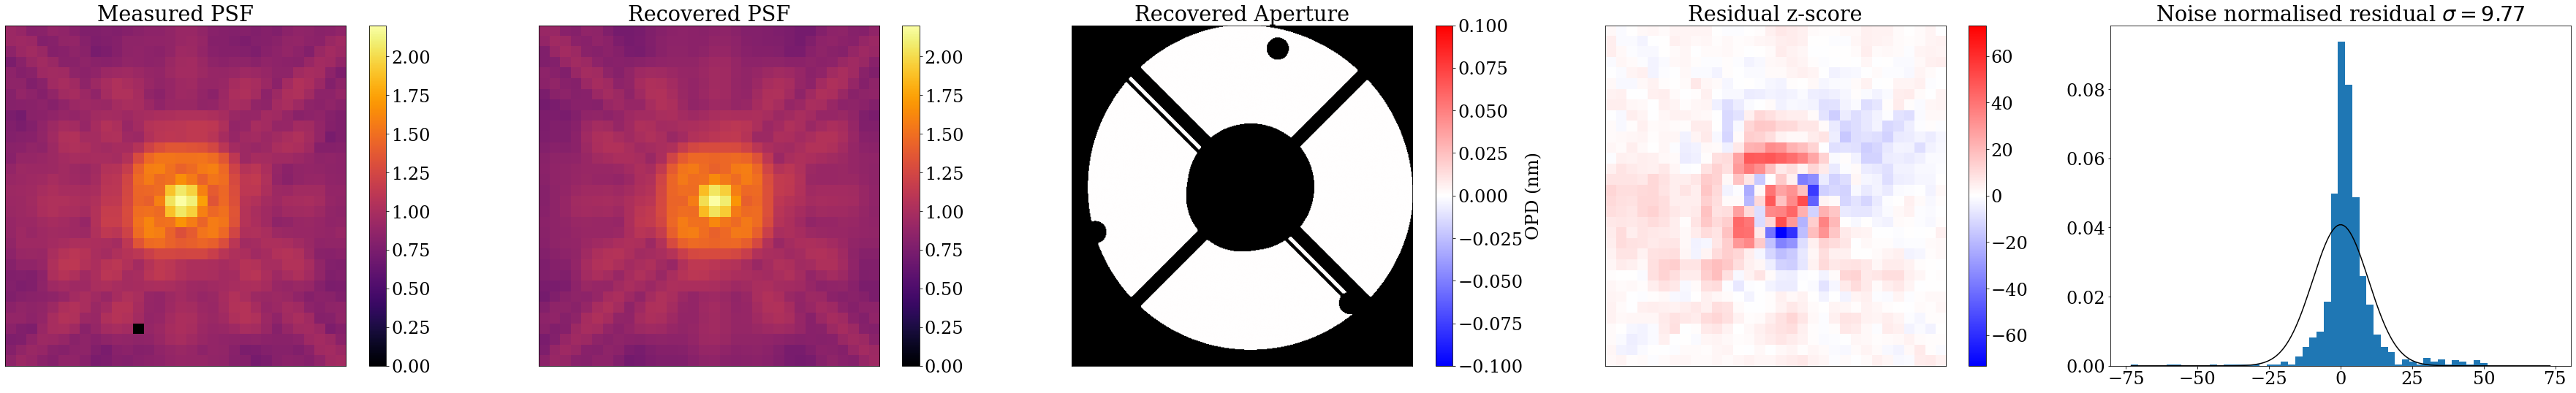

In [ ]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

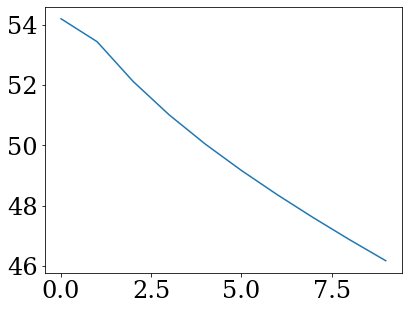

In [ ]:
plt.plot(np.asarray(losses[-10:])/(len(exposures_single)*wid**2))

In [ ]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [ ]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 300, nbatches=20)

[6.01876627e-01 4.24804809e-02 6.29515132e-03 6.02774578e-03
 4.56387446e-03 4.51931786e-03 3.85523265e-02 1.98515331e-02
 4.44497233e-02 9.72814310e-02 1.00004914e-01 1.15195960e-02
 1.20230075e-02 5.68628206e-03 5.71827261e-03 1.43624482e-02
 1.40787144e-02 7.72224408e-02 3.41545278e-01 4.25660618e-02
 8.02641987e-01 4.06419671e-02 5.86363738e-03 5.78449525e-03
 4.34307554e-03 4.24144480e-03 3.67121349e-02 1.76973099e-02
 4.29272625e-02 7.23168152e-02 7.82920950e-02 1.13571743e-02
 1.15340951e-02 5.41722300e-03 5.46134106e-03 1.33988644e-02
 1.33476413e-02 7.28686059e-02 2.72181674e-01 3.62230376e-02
 9.88779439e-07 1.01411927e-06 5.95456064e-05 5.93172271e-05
 5.75320514e-05 5.58838302e-05 6.88614764e-05 4.93923899e-05
 4.02805213e-07 4.10503937e-07 4.01405129e-07 4.02169936e-07
 1.02867657e-06 9.04217611e-07 1.68087310e-03 1.13075105e-02
 3.38886946e-02 1.16401607e-01 2.09969033e-01 4.44488762e-01
 1.38182317e+00 4.10368503e+00]


  0%|          | 0/300 [00:00<?, ?it/s]

93196.31530411223 {'aberrations': {'n9nk29c8q': Array([  -19.88184085,   -17.35713597,  -259.81926368,  1429.20796032,
         614.2824246 ,   372.41498178,  -463.86950788,  -130.2225578 ,
         115.59484759,  -150.32123409,   -89.89820095, -1017.08241839,
         416.76018748,    97.42412547,  -505.87366449,   174.35162864,
           2.76938355,    48.53324271,  -143.18458195,  -276.38548616],      dtype=float64), 'n9nk29d1q': Array([    8.02654452,    53.23630399,   969.44093597,  1163.91496376,
         285.66517635,  2181.05120177,   -49.44948626,  -767.78508868,
        -426.14443976,  -373.80425742,   333.37571564,  -891.8510469 ,
        -191.09940412, -1459.73141082,  -637.67708865,   150.50316136,
         264.60234592,   154.20189731,   -64.10267142,  -398.0789249 ],      dtype=float64)}, 'bias': {'n9nk29c8q': Array(-38201.22773781, dtype=float64), 'n9nk29d1q': Array(-43129.32360185, dtype=float64)}, 'cold_mask_shear': {'global': Array([2069.60623459, 3209.25554584], dt

In [ ]:
len(losses)

300

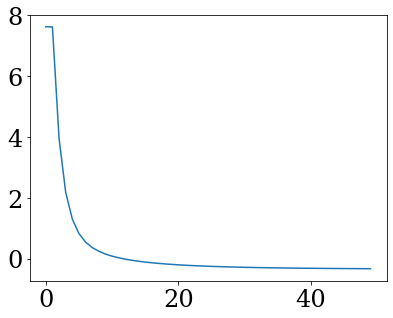

In [ ]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [ ]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

8
1.109138379787173
1.1417308572691567


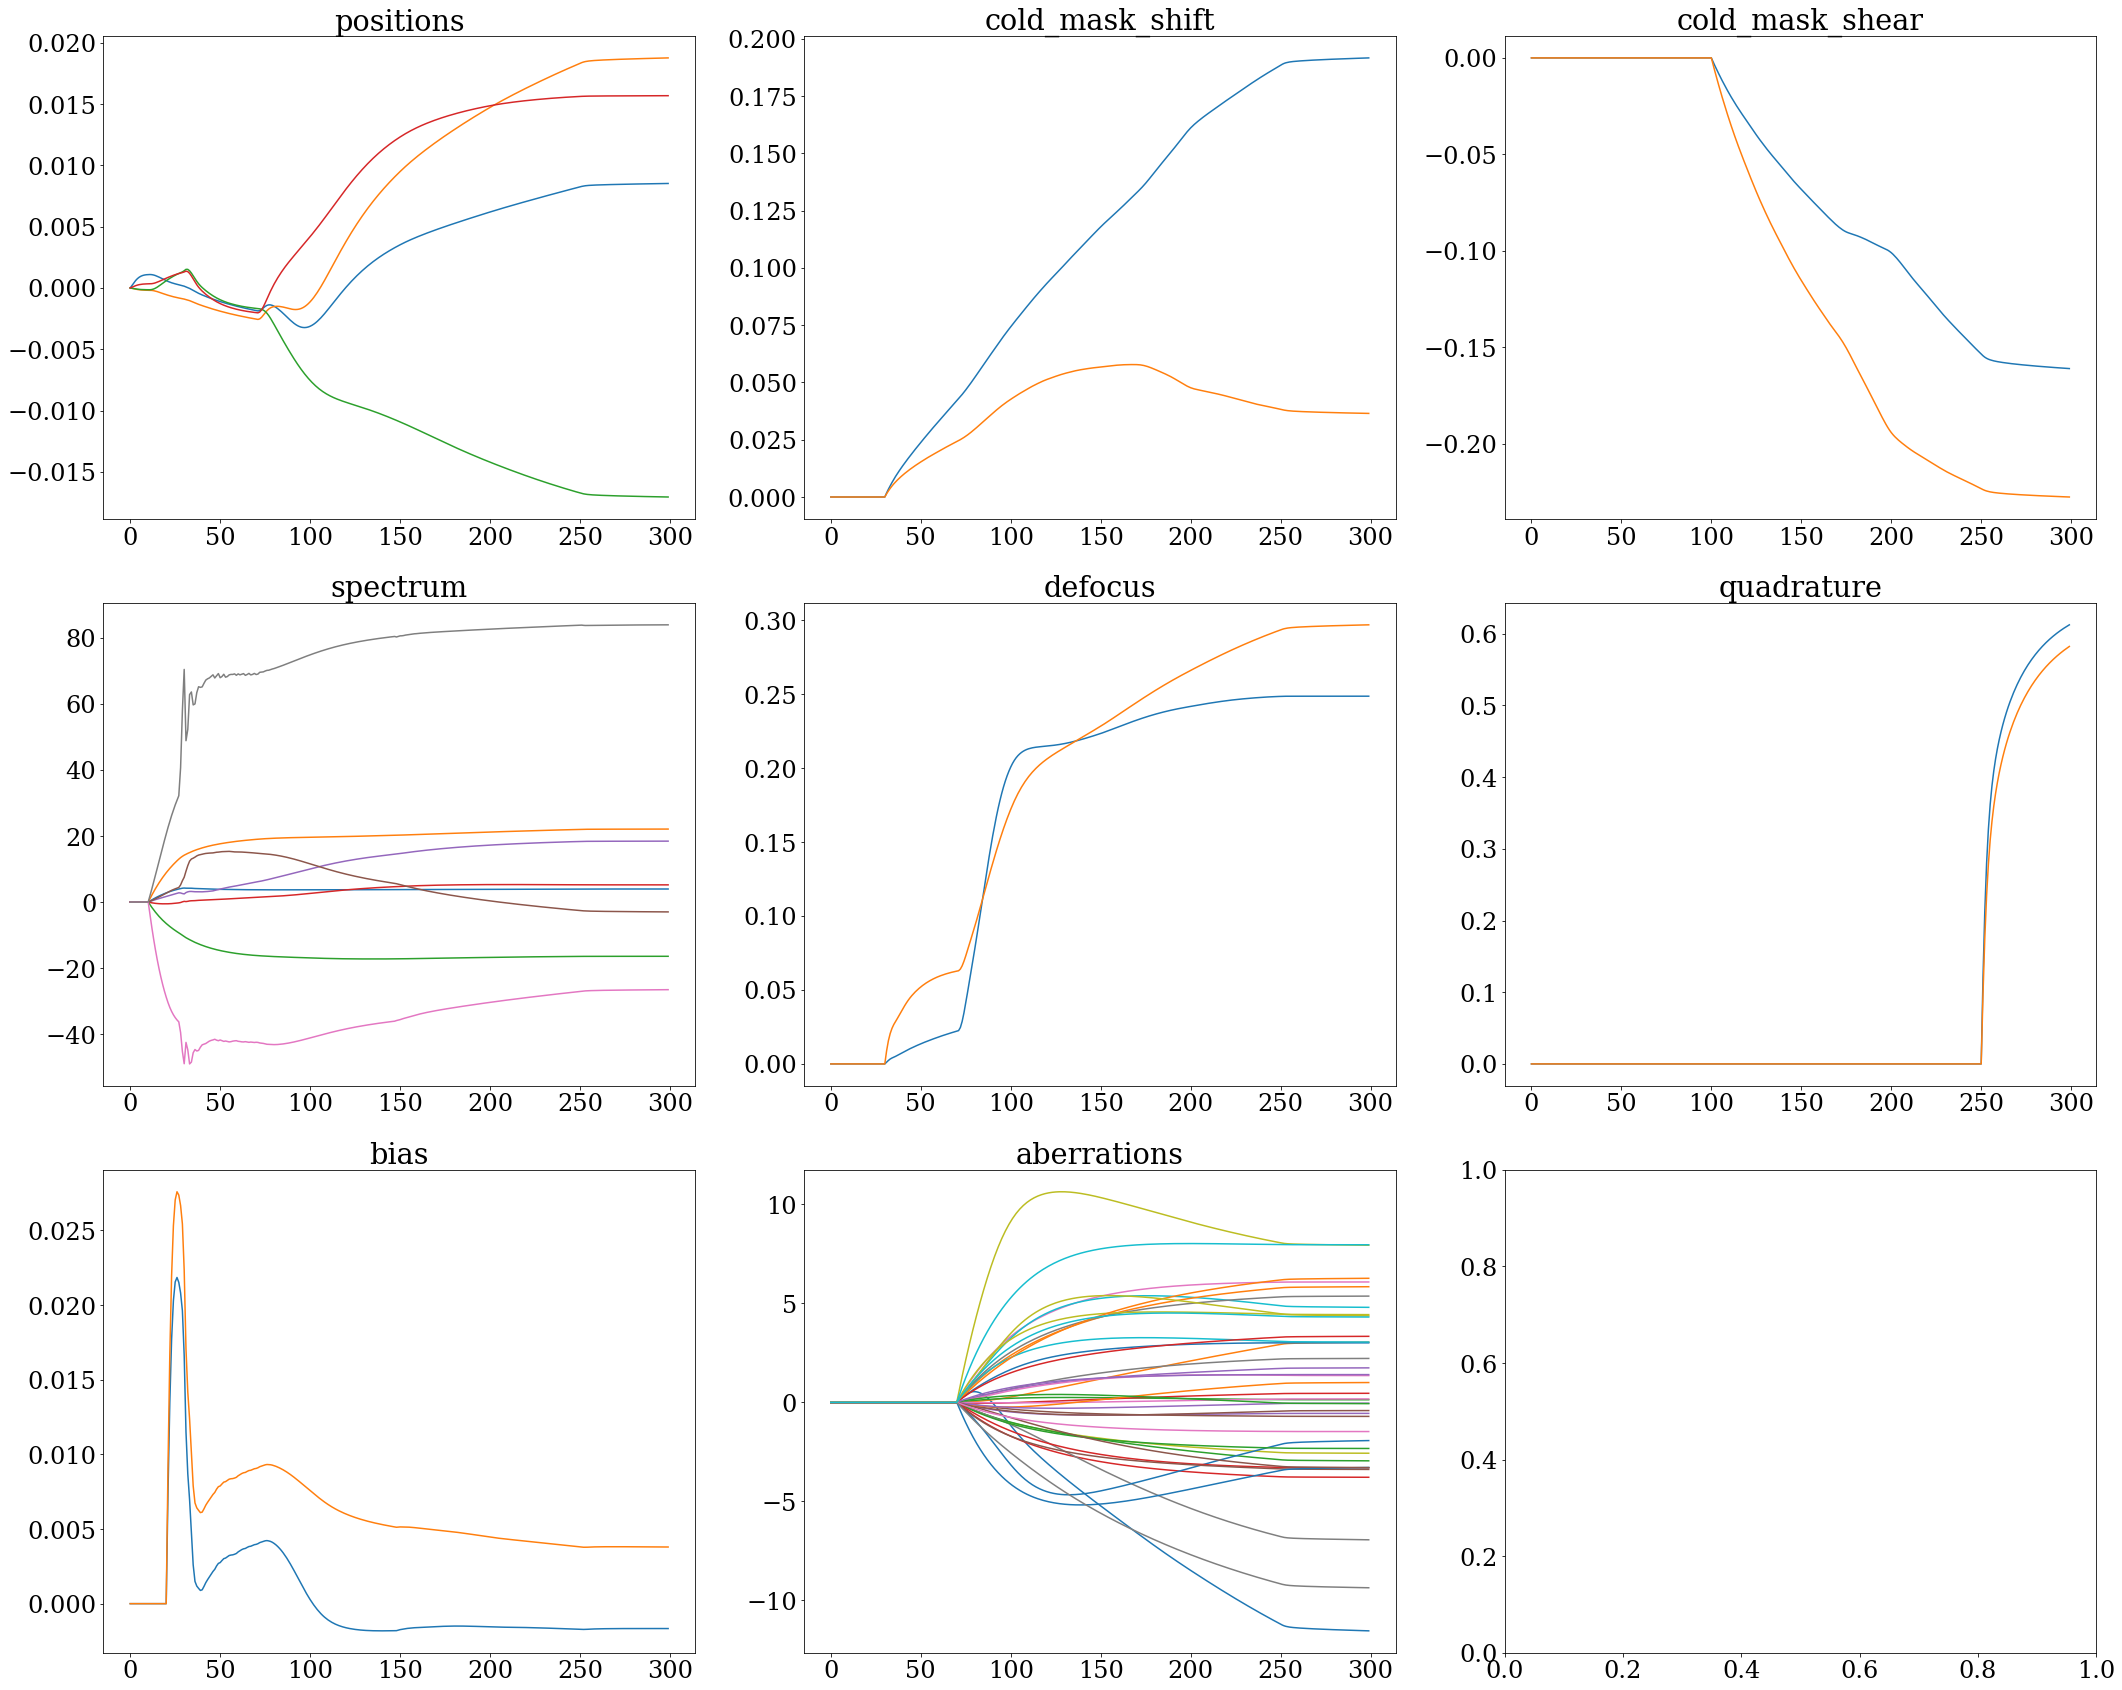

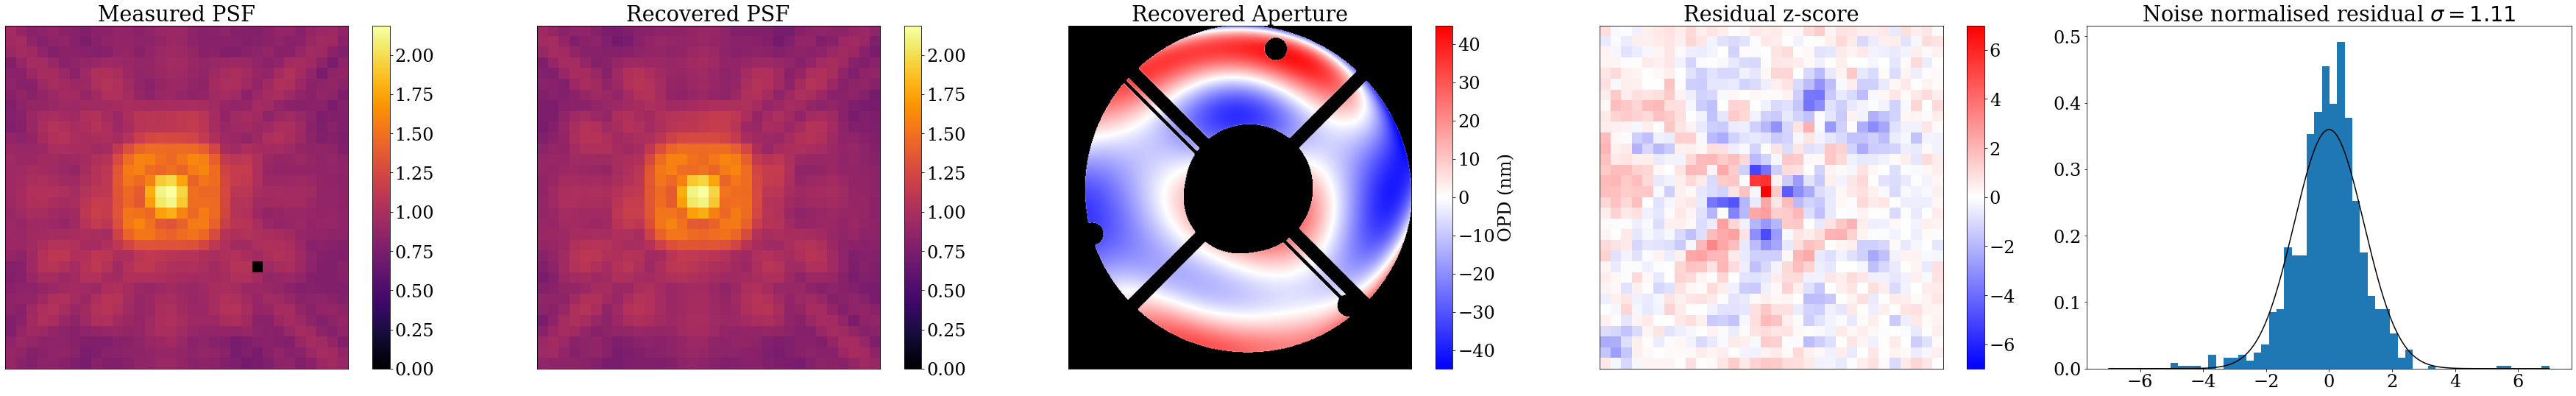

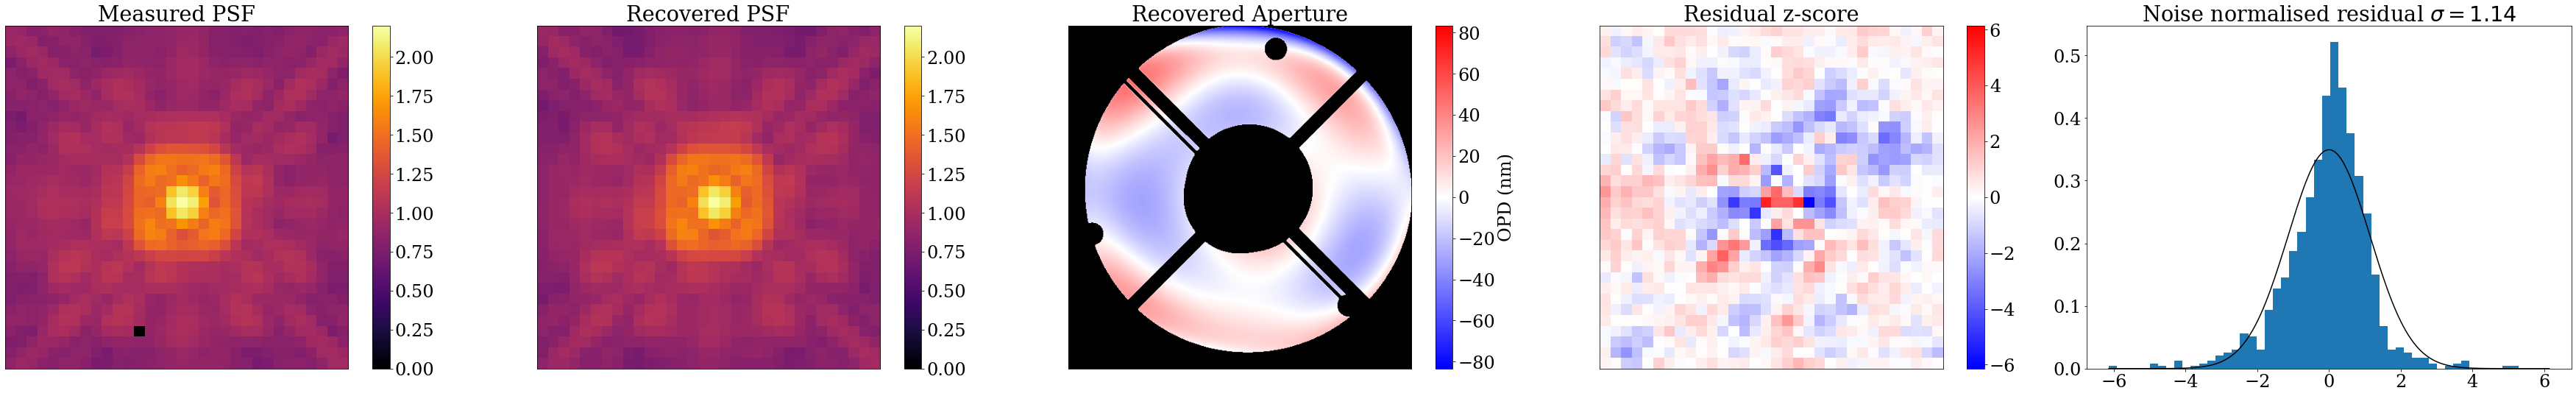

In [ ]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [ ]:
params_history[-1]["spectrum"]["U20581_F110W"]

Array([112.43968656,  25.86470553, -20.28390297,   4.54838825,
        19.30134208,  -2.46078329, -43.86218787,  88.70426215],      dtype=float64)

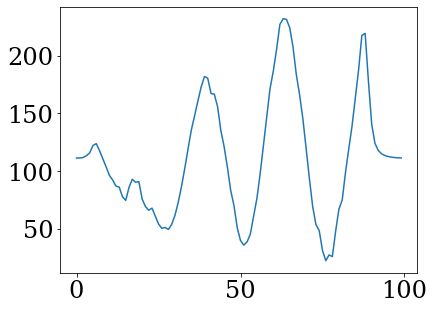

In [ ]:
spec = PreCombinedBasisSpectrum(wavels_binned_upsampled, params_history[19]["spectrum"]["U20581_F110W"], vects_binned_upsampled)
plt.plot(spec.spec_weights())

In [ ]:
# stop

In [ ]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single, project=True, diag=True)

In [ ]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([-31.23606582,   7.33926135,  -5.26811596,   2.44314528,
          -5.94821992,  -5.24215508,   4.40916799,   4.57227672,
         -19.5673856 ,  -1.34030975,   0.80610329,  11.84019375,
          -9.27443823,  -1.20458077,   0.75437266,   0.58619858,
           0.50973673,  -0.45121273,  -1.14885499,   3.80712629],      dtype=float64),
  'n9nk29d1q': Array([ 12.65646027,  -5.84940958, -14.4177703 ,   2.82241091,
           0.46547228,  -9.77087912,  16.39001463,  -2.01279933,
           2.30177438,  -1.24437653,  -1.28766651,  12.66977569,
          -8.99292316,  -0.08598661,   1.53561026,  -4.30690427,
          -2.07515837,  -0.56356911,  -5.02566549,  -1.94922448],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(-0.00909422, dtype=float64),
  'n9nk29d1q': Array(-0.00047777, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.18028785, -0.17532934], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.30504361, 5.59733906], dtype=floa

In [ ]:
#sol.stats

0.99950836687774
0.9976320304869769


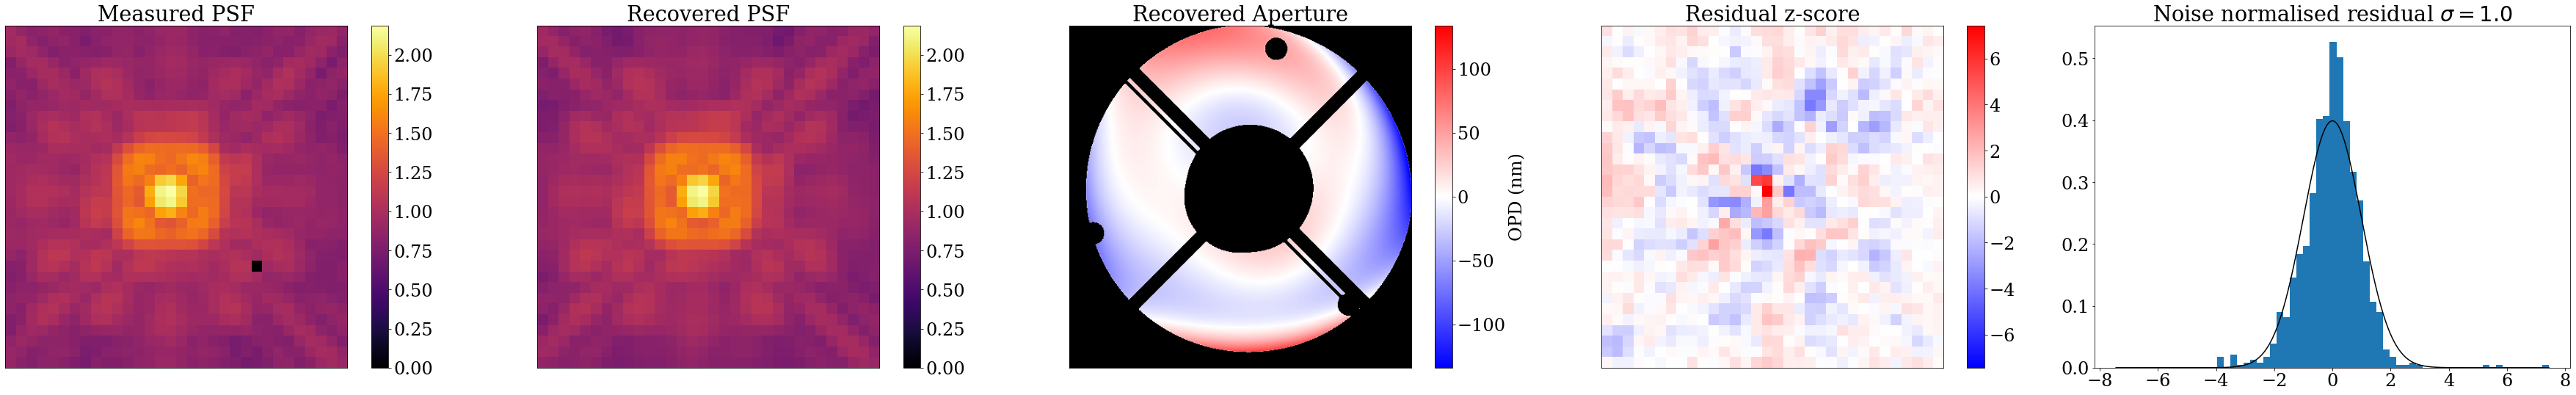

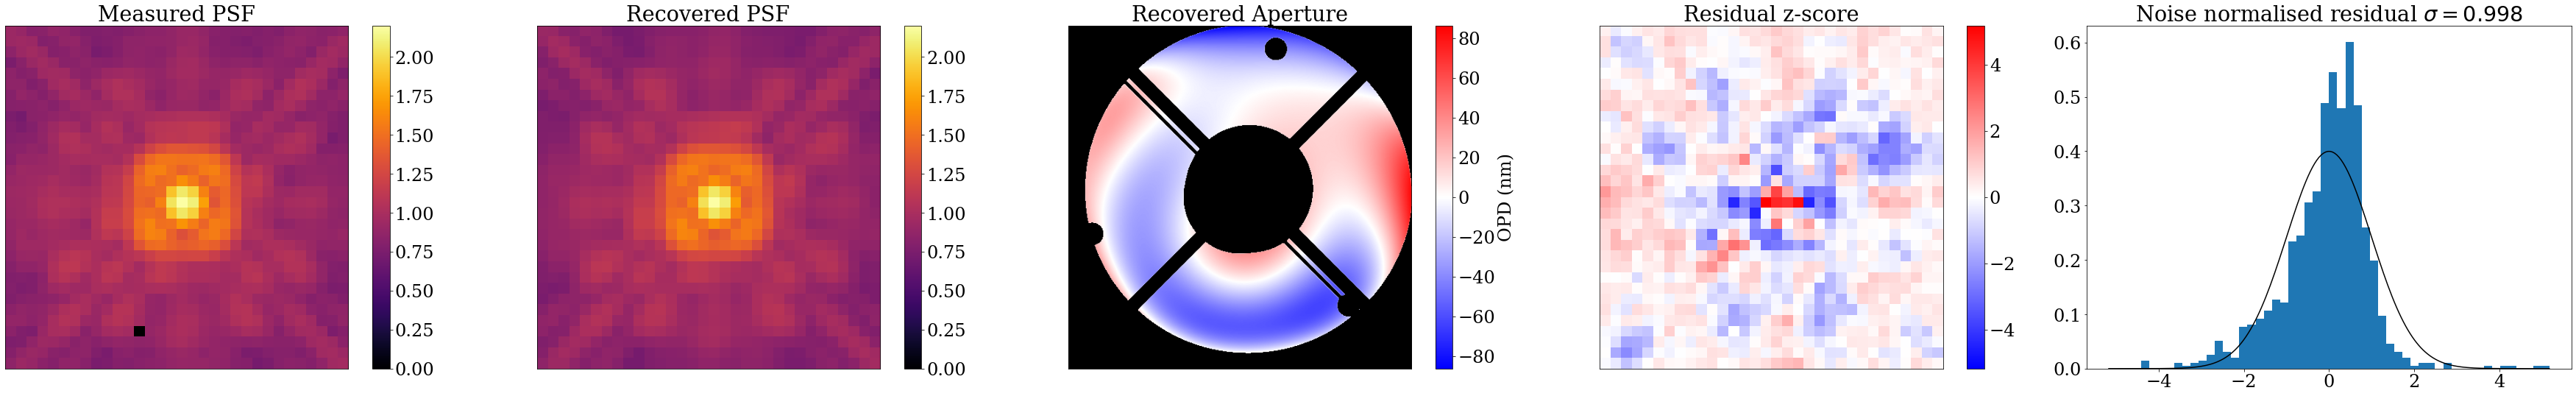

In [ ]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [ ]:
# calculate spectrum

In [ ]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [ ]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([-31.23606582,   7.33926135,  -5.26811596,   2.44314528,
          -5.94821992,  -5.24215508,   4.40916799,   4.57227672,
         -19.5673856 ,  -1.34030975,   0.80610329,  11.84019375,
          -9.27443823,  -1.20458077,   0.75437266,   0.58619858,
           0.50973673,  -0.45121273,  -1.14885499,   3.80712629],      dtype=float64),
  'n9nk29d1q': Array([ 12.65646027,  -5.84940958, -14.4177703 ,   2.82241091,
           0.46547228,  -9.77087912,  16.39001463,  -2.01279933,
           2.30177438,  -1.24437653,  -1.28766651,  12.66977569,
          -8.99292316,  -0.08598661,   1.53561026,  -4.30690427,
          -2.07515837,  -0.56356911,  -5.02566549,  -1.94922448],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(-0.00909422, dtype=float64),
  'n9nk29d1q': Array(-0.00047777, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.18028785, -0.17532934], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.30504361, 5.59733906], dtype=floa

In [ ]:
f = lambda params: loss_fn(ModelParams(final_params.params|params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, {"spectrum":params_history[-1]["spectrum"]}, nbatches=2*len(exposures_single))

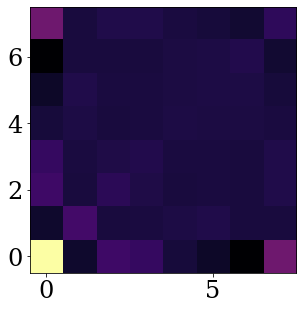

In [ ]:
plt.imshow(F[-(npoly):, -(npoly):])

In [ ]:
cov_f110w = np.linalg.inv(F)[-(npoly):, -(npoly):]
spectrum_err = np.diag(np.sqrt(np.abs(cov_f110w)))


In [ ]:
final_params

ModelParams(
  params={
    'aberrations': {'n9nk29c8q': f64[20], 'n9nk29d1q': f64[20]},
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'spectrum': {'U20581_F110W': f64[8]}
  }
)

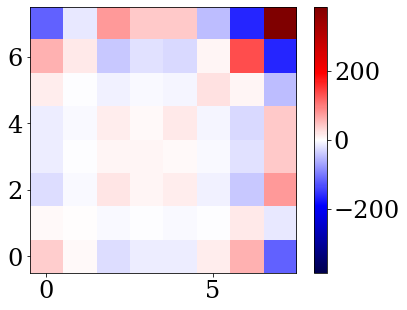

In [ ]:
plt.imshow(cov_f110w, cmap='seismic', vmin=-np.max(np.abs(cov_f110w)), vmax=np.max(np.abs(cov_f110w)))
plt.colorbar()


In [ ]:
np.sqrt(np.diag(cov_f110w))

Array([ 6.14951831,  1.58995578,  4.27188705,  2.72607891,  4.04633653,
        4.68806177, 11.49473091, 19.60495978], dtype=float64)

In [ ]:
final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(np.diag(cov_f110w))

Array([19.17187269, 74.15161066, 27.59852512, 43.24811796, 29.13691963,
       25.14851294, 10.25668048,  6.01367121], dtype=float64)

In [ ]:
# final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(vals)

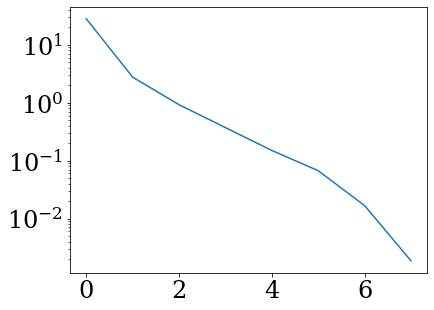

In [ ]:
vals, vects = np.linalg.eig(F[-(npoly):, -(npoly):])#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

In [ ]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels*2)

In [ ]:
#final_params = ModelParams(params_history[-1])

In [ ]:
fname = "2M1439.fits"
data = fits.getdata(fname, ext=0).astype(np.float32)

In [ ]:
cov_f110w.shape

(8, 8)

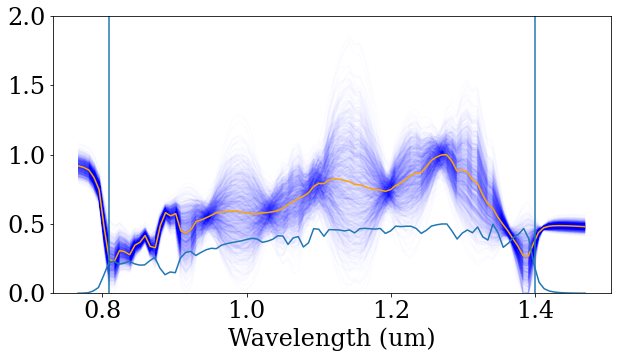

In [ ]:
plt.figure(figsize=(10,5))



spec = PreCombinedBasisSpectrum(wavels_binned_upsampled, final_params.get("spectrum.U20581_F110W"), vects_binned_upsampled)
wv = wavels_binned_upsampled

sp = spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)

smax = np.max(sp)

sp = sp/smax

plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.U20581_F110W"), (cov_f110w))
    spec = PreCombinedBasisSpectrum(wavels_binned_upsampled, coeffs, vects_binned_upsampled)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
#plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))
plt.plot(wavels*1e6, bandpass/np.max(bandpass)*0.5)

plt.xlabel("Wavelength (um)")
plt.ylim(0,2)
plt.axvline(0.81)
plt.axvline(1.4)

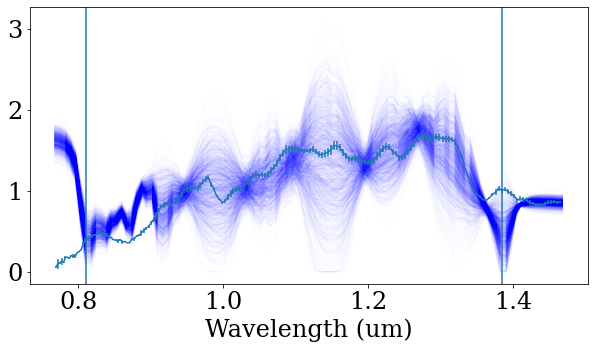

In [ ]:
plt.figure(figsize=(10,5))



spec = PreCombinedBasisSpectrum(wavels_binned_upsampled, final_params.get("spectrum.U20581_F110W"), vects_binned_upsampled)
wv = wavels_binned_upsampled

sp = spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)

smax = np.mean(sp)*0.9

sp = sp/smax

#plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.U20581_F110W"), (cov_f110w))
    spec = PreCombinedBasisSpectrum(wavels_binned_upsampled, coeffs, vects_binned_upsampled)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))

plt.xlabel("Wavelength (um)")
plt.axvline(0.81)
plt.axvline(1.385)

In [ ]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([-31.23606582,   7.33926135,  -5.26811596,   2.44314528,
          -5.94821992,  -5.24215508,   4.40916799,   4.57227672,
         -19.5673856 ,  -1.34030975,   0.80610329,  11.84019375,
          -9.27443823,  -1.20458077,   0.75437266,   0.58619858,
           0.50973673,  -0.45121273,  -1.14885499,   3.80712629],      dtype=float64),
  'n9nk29d1q': Array([ 12.65646027,  -5.84940958, -14.4177703 ,   2.82241091,
           0.46547228,  -9.77087912,  16.39001463,  -2.01279933,
           2.30177438,  -1.24437653,  -1.28766651,  12.66977569,
          -8.99292316,  -0.08598661,   1.53561026,  -4.30690427,
          -2.07515837,  -0.56356911,  -5.02566549,  -1.94922448],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(-0.00909422, dtype=float64),
  'n9nk29d1q': Array(-0.00047777, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.18028785, -0.17532934], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.30504361, 5.59733906], dtype=floa

In [ ]:
plt.figure(figsize=(10,10))

nw = nwavels
wv, filt = calc_throughput("F110W", nwavels=nw)
big_basis = spectrum_basis_f110w#load_spectrum_basis("F110W", nw, npoly)

spec = CombinedBasisSpectrum(wv, filt, final_params.get("spectrum.U20581_F110W"), big_basis)

sp = spec.spec_weights()/spec.flux*spec.proper_flux()#/(wv*1e6)


TypeError: mul got incompatible shapes for broadcasting: (355,), (50,).

<Figure size 720x720 with 0 Axes>

In [ ]:
np.savez("spectrum_iterative.npz", weights=sp,params=final_params.params)